In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [26]:

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [27]:
plt.rcParams.update({
    "figure.facecolor": "#0d0d1f",
    "axes.facecolor":   "#13132b",
    "axes.edgecolor":   "#444",
    "axes.labelcolor":  "white",
    "xtick.color":      "white",
    "ytick.color":      "white",
    "text.color":       "white",
    "grid.color":       "#2b2b50",
    "grid.linestyle":   "--",
    "grid.alpha":       0.4,
})

In [28]:
COLORS  = ["#f472b6", "#818cf8", "#34d399"]
SPECIES = ["Setosa", "Versicolor", "Virginica"]
FEATURES = ["Sepal Length", "Sepal Width", "Petal Length", "Petal Width"]

In [ ]:
df = pd.read_csv("D:\\codealpa\\iris\\Iris.csv")

In [30]:
df = df.drop(columns=["Id"])

In [31]:
df.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]

In [32]:
df["species"] = df["species"].str.replace("Iris-", "").str.capitalize()
df["target"]  = df["species"].map({"Setosa": 0, "Versicolor": 1, "Virginica": 2})

In [33]:
df.head(10)


,sepal_length,sepal_width,petal_length,petal_width,species,target
0,5.1,3.5,1.4,0.2,Setosa,0
1,4.9,3.0,1.4,0.2,Setosa,0
2,4.7,3.2,1.3,0.2,Setosa,0
3,4.6,3.1,1.5,0.2,Setosa,0
4,5.0,3.6,1.4,0.2,Setosa,0
5,5.4,3.9,1.7,0.4,Setosa,0
6,4.6,3.4,1.4,0.3,Setosa,0
7,5.0,3.4,1.5,0.2,Setosa,0
8,4.4,2.9,1.4,0.2,Setosa,0
9,4.9,3.1,1.5,0.1,Setosa,0


In [34]:
df.describe().round(2)


,sepal_length,sepal_width,petal_length,petal_width,target
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.05,3.76,1.20,1.00
std,0.83,0.43,1.76,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


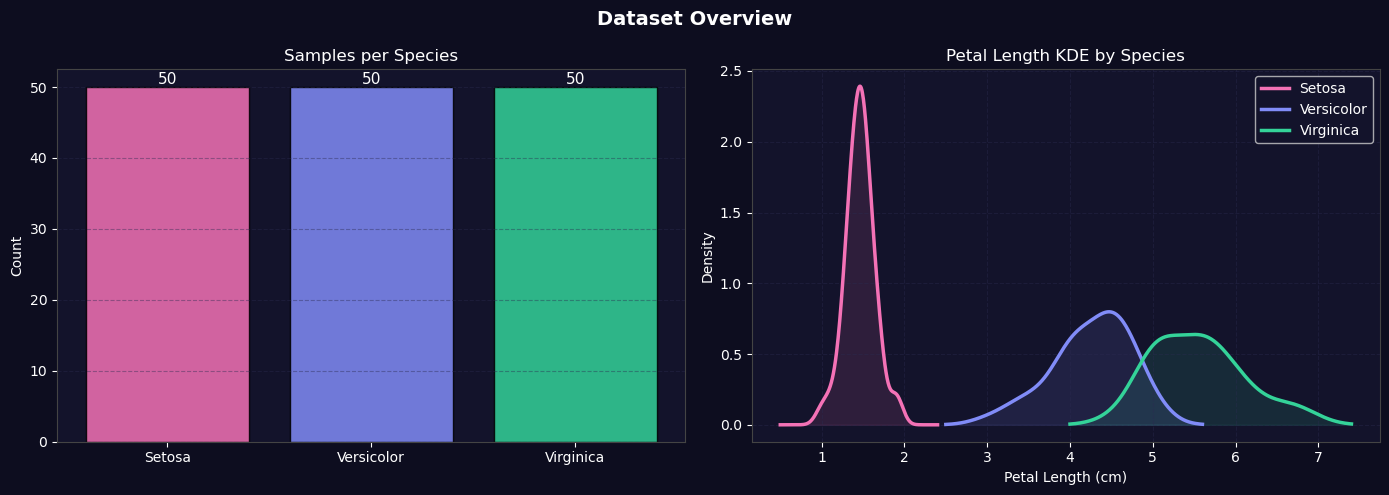

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Dataset Overview", fontsize=14, fontweight="bold", color="white")

counts = df["species"].value_counts().reindex(SPECIES)
bars = ax1.bar(SPECIES, counts.values, color=COLORS, alpha=0.85, edgecolor="black")
for bar, cnt in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(cnt), ha="center", fontsize=11, color="white")
ax1.set_ylabel("Count")
ax1.set_title("Samples per Species", color="white")
ax1.grid(True, axis="y")

for sp, color in zip(SPECIES, COLORS):
    subset = df[df["species"] == sp]["petal_length"]
    xs = np.linspace(subset.min() - 0.5, subset.max() + 0.5, 300)
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(subset)
    ys  = kde(xs)
    ax2.plot(xs, ys, color=color, linewidth=2.5, label=sp)
    ax2.fill_between(xs, ys, alpha=0.12, color=color)
ax2.set_xlabel("Petal Length (cm)")
ax2.set_ylabel("Density")
ax2.set_title("Petal Length KDE by Species", color="white")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight", facecolor="#0d0d1f")
plt.show()


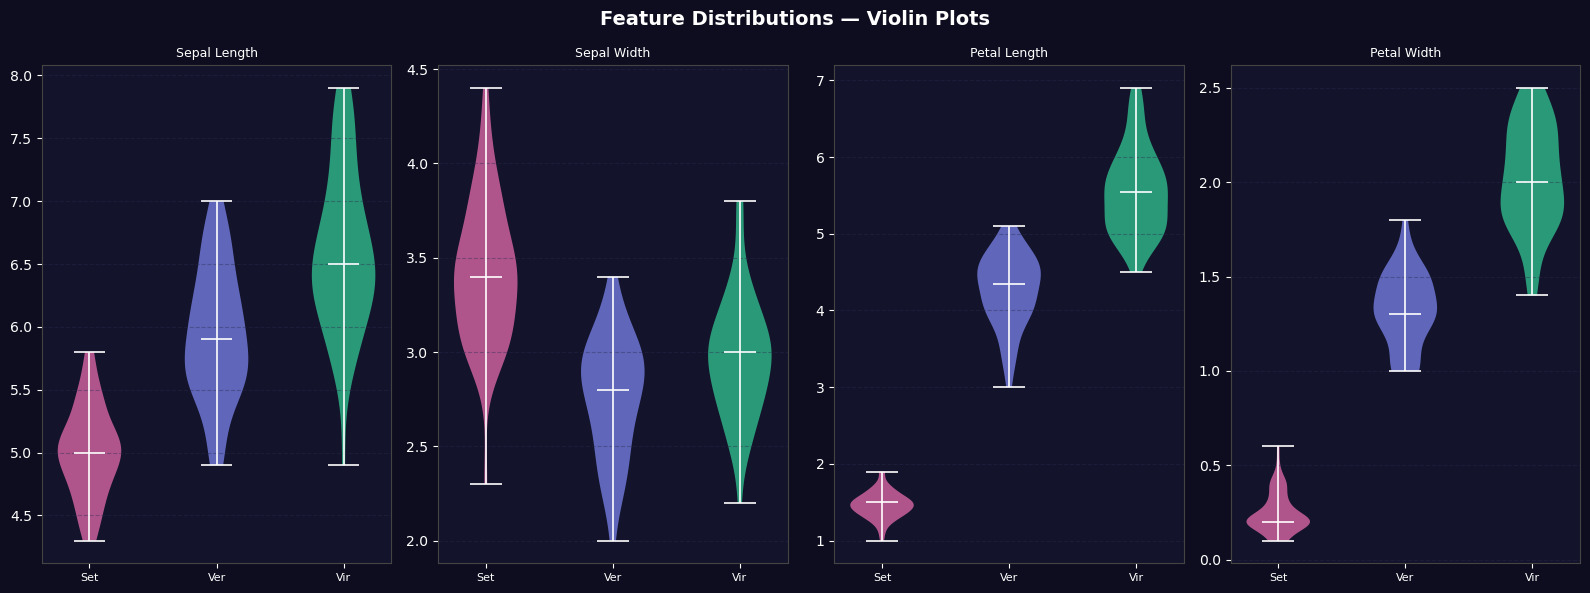

In [36]:
feat_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
fig, axes = plt.subplots(1, 4, figsize=(16, 6))
fig.suptitle("Feature Distributions — Violin Plots", fontsize=14, fontweight="bold", color="white")

for ax, col, label in zip(axes, feat_cols, FEATURES):
    data = [df[df["species"] == sp][col].values for sp in SPECIES]
    parts = ax.violinplot(data, positions=[1, 2, 3], showmedians=True)
    for body, color in zip(parts["bodies"], COLORS):
        body.set_facecolor(color)
        body.set_alpha(0.7)
    for part in ["cmedians", "cmins", "cmaxes", "cbars"]:
        parts[part].set_color("white")
        parts[part].set_linewidth(1.2)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["Set", "Ver", "Vir"], fontsize=8)
    ax.set_title(label, fontsize=9, color="white")
    ax.grid(True, axis="y")

plt.tight_layout()
plt.savefig("eda_violin.png", dpi=150, bbox_inches="tight", facecolor="#0d0d1f")
plt.show()


In [37]:
X_raw = df[["sepal_length", "sepal_width", "petal_length", "petal_width"]].values
y_raw = df["species"].values


In [38]:
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X_raw)
print(f"Missing values before imputer: {np.isnan(X_raw).sum()}")
print(f"Missing values after  imputer: {np.isnan(X).sum()}")

Missing values before imputer: 0
Missing values after  imputer: 0


In [39]:
le = LabelEncoder()
y  = le.fit_transform(y_raw)
print(f"\nLabel Encoding mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")


Label Encoding mapping: {'Setosa': np.int64(0), 'Versicolor': np.int64(1), 'Virginica': np.int64(2)}


In [40]:
ohe = OneHotEncoder(sparse_output=False)
y_ohe = ohe.fit_transform(y.reshape(-1, 1))
print(f"\nOneHotEncoder output (first 5 rows):\n{y_ohe[:5]}")
print("(columns = Setosa | Versicolor | Virginica)")


OneHotEncoder output (first 5 rows):
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]
(columns = Setosa | Versicolor | Virginica)


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7, stratify=y
)


In [42]:
scaler  = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

Train: 112 samples | Test: 38 samples


In [43]:
models = {
    "KNN (k=3)":     KNeighborsClassifier(n_neighbors=3),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=7),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=7),
    "SVM (RBF)":     SVC(kernel="rbf", C=1.0, random_state=7),
}


In [44]:
for name, model in models.items():
    cv   = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc  = accuracy_score(y_test, pred)
    results[name] = {"model": model, "cv": cv.mean(), "acc": acc, "pred": pred}
    print(f"{name:<20} {cv.mean()*100:>9.2f}%  {acc*100:>9.2f}%")


KNN (k=3)                95.53%      97.37%
Decision Tree            96.48%      94.74%
Random Forest            96.40%      97.37%
SVM (RBF)                94.62%      97.37%


In [45]:
best_name = max(results, key=lambda k: results[k]["acc"])
best      = results[best_name]

In [46]:
print(f"Classification Report — {best_name}\n")
print(classification_report(y_test, best["pred"], target_names=SPECIES))


Classification Report — KNN (k=3)

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        13
  Versicolor       1.00      0.92      0.96        13
   Virginica       0.92      1.00      0.96        12

    accuracy                           0.97        38
   macro avg       0.97      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



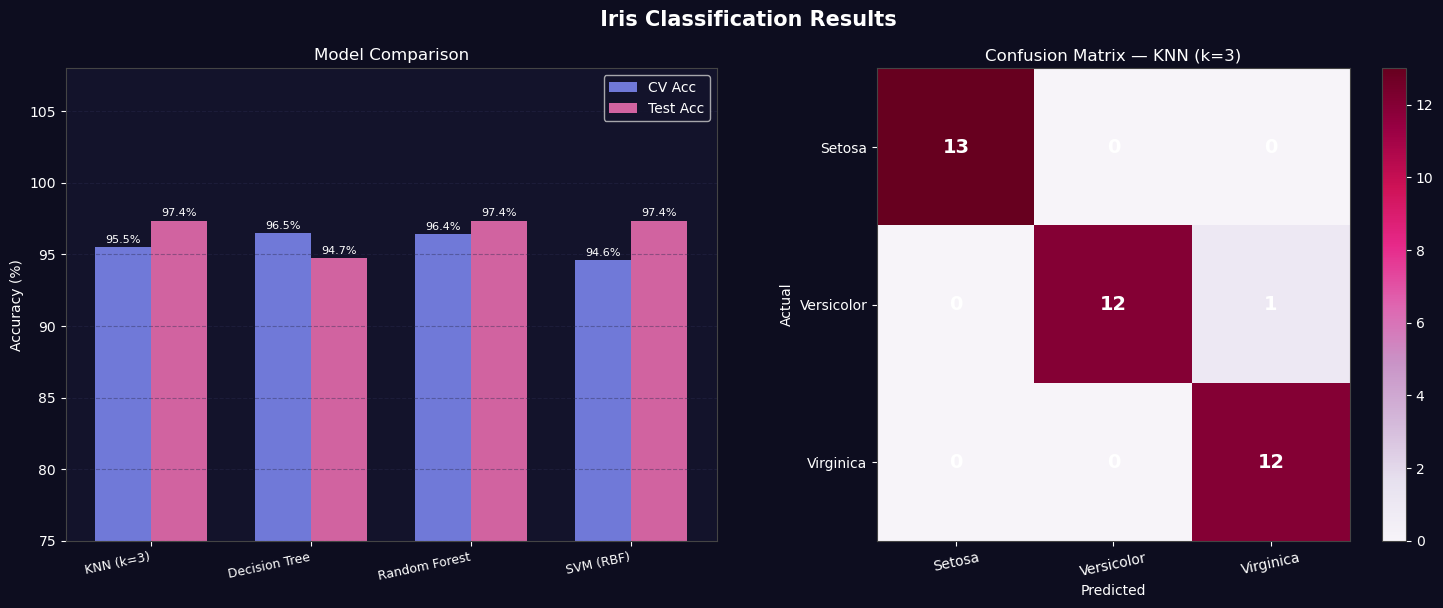

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(" Iris Classification Results", fontsize=15, fontweight="bold", color="white")

names     = list(results.keys())
cv_vals   = [v["cv"]  * 100 for v in results.values()]
test_vals = [v["acc"] * 100 for v in results.values()]
x, w      = np.arange(len(names)), 0.35

b1 = ax1.bar(x - w/2, cv_vals,   w, label="CV Acc",   color="#818cf8", alpha=0.85)
b2 = ax1.bar(x + w/2, test_vals, w, label="Test Acc", color="#f472b6", alpha=0.85)
for bar in list(b1) + list(b2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{bar.get_height():.1f}%", ha="center", fontsize=8, color="white")
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=12, ha="right", fontsize=9)
ax1.set_ylim(75, 108)
ax1.set_ylabel("Accuracy (%)")
ax1.set_title("Model Comparison", color="white")
ax1.legend()
ax1.grid(True, axis="y")

cm = confusion_matrix(y_test, best["pred"])
im = ax2.imshow(cm, cmap="PuRd")
plt.colorbar(im, ax=ax2)
for i in range(3):
    for j in range(3):
        ax2.text(j, i, str(cm[i, j]), ha="center", va="center",
                 fontsize=14, color="white", fontweight="bold")
ax2.set_xticks([0, 1, 2]); ax2.set_xticklabels(SPECIES, rotation=12)
ax2.set_yticks([0, 1, 2]); ax2.set_yticklabels(SPECIES)
ax2.set_xlabel("Predicted"); ax2.set_ylabel("Actual")
ax2.set_title(f"Confusion Matrix — {best_name}", color="white")

plt.tight_layout()
plt.savefig("model_results.png", dpi=150, bbox_inches="tight", facecolor="#0d0d1f")
plt.show()


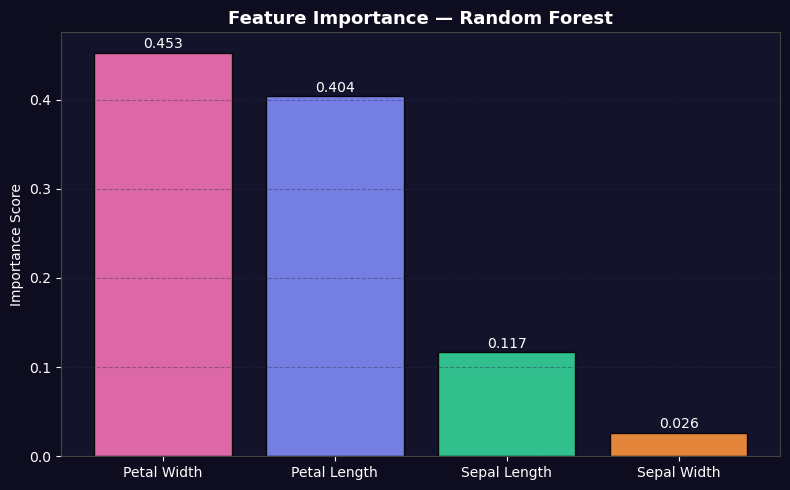

In [48]:
rf = results["Random Forest"]["model"]
importances = rf.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    range(4), importances[sorted_idx],
    color=["#f472b6", "#818cf8", "#34d399", "#fb923c"],
    edgecolor="black", alpha=0.9
)
ax.set_xticks(range(4))
ax.set_xticklabels([FEATURES[i] for i in sorted_idx], fontsize=10)
ax.set_ylabel("Importance Score")
ax.set_title("Feature Importance — Random Forest", fontsize=13, color="white", fontweight="bold")
for bar, imp in zip(bars, importances[sorted_idx]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{imp:.3f}", ha="center", fontsize=10, color="white")
ax.grid(True, axis="y")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight", facecolor="#0d0d1f")
plt.show()

